<a href="https://colab.research.google.com/github/reynaudnangue28/test/blob/main/CO2_Emission_Project_Interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ruff

Mounted at /content/drive


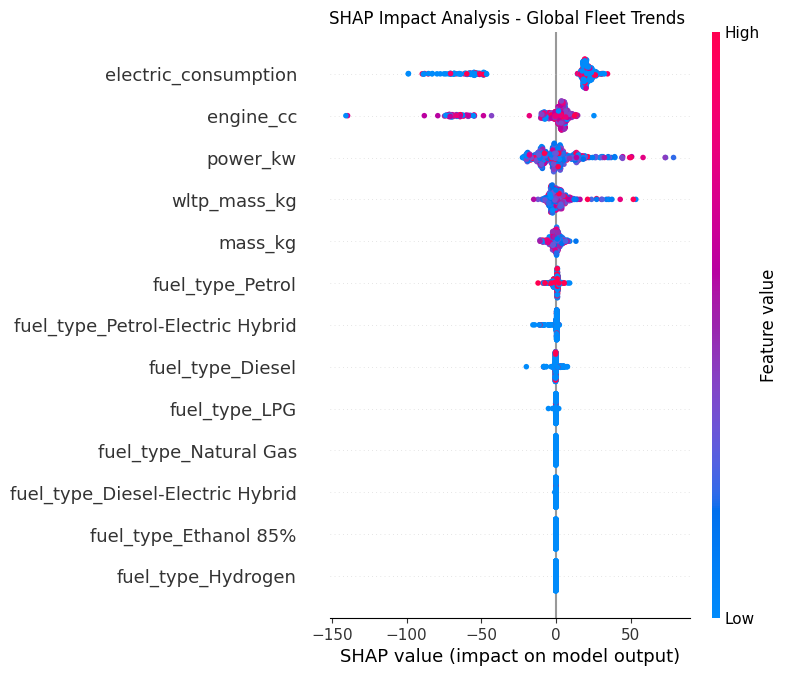

In [1]:
# Interpretability
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

import shap
import matplotlib.pyplot as plt


# Google Colab to access and mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ---  load a mapping csv---
try:
    mapping_df = pd.read_csv('/content/drive/MyDrive/Data/EEA2024CO2Data/eea_column_mapping_with_nulls.csv')
    cols_to_keep = mapping_df[mapping_df['keep'] == True]
    rename_map = dict(zip(cols_to_keep['column_name_original'], cols_to_keep['column_name_new']))
except FileNotFoundError:
    print("Error : file is missing.")
    exit()

# ---  load the EEA file  ---

df1 = pd.read_csv(
    "/content/drive/MyDrive/Data/EEA2024CO2Data/data.csv",
    nrows=7000000,
    low_memory=False
)

#Reading Between Raws 7 million and 10.8 million

df2 = pd.read_csv(
    "/content/drive/MyDrive/Data/EEA2024CO2Data/data.csv",
    skiprows=range(1, 7_000_001),  # skip header + first 7M rows
    low_memory=False
)

# ---  Filter and rename ---
# choose only the columns with 'keep=True'
df1 = df1[rename_map.keys()]
# Rename the columns
df1 = df1.rename(columns=rename_map)

# choose only the columns with 'keep=True'
df2 = df2[rename_map.keys()]
# Rename the columns
df2 = df2.rename(columns=rename_map)

#Concat of df1 and df2
df = pd.concat([df1, df2], axis=0, ignore_index=True)

fuel_map   = {
    'petrol': "Petrol",
    'diesel': "Diesel",
    'petrol/electric': "Petrol-Electric Hybrid",
    'diesel/electric': "Diesel-Electric Hybrid",
    'electric': "100% Electric",
    'lpg': "LPG",
    'ng': "Natural Gas",
    'e85': "Ethanol 85%",
    'hydrogen': "Hydrogen",
    'unknown': "Unknown",
    'es': "Petrol"
}

df['fuel_type'] = df['fuel_type'].str.strip().str.lower().replace(fuel_map)

#  Basic Preprocessing

#numeric features
features = [
    "mass_kg",
    "wltp_mass_kg",
    "engine_cc",
    "power_kw",
    "electric_consumption",
    "fuel_type"
]
target = 'co2_wltp'

df['engine_cc'] = df['engine_cc'].fillna(0)


df['electric_consumption'] = df['electric_consumption'].fillna(0)


# Drop rows with missing values in these specific columns
df = df.dropna(subset=features + [target])
X = pd.get_dummies(df[features], columns=['fuel_type'], drop_first=True)
y = df[target]

#  Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

#  Statistical & Qualitative Summary
def project_final_interpretation(model, X_test):
    # SHAP Interpretation (Sampled for speed)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test.sample(500))

    # Feature Impact Plot
    plt.figure(figsize=(10,6))
    shap.summary_plot(shap_values, X_test.sample(500), show=False)
    plt.title(f"SHAP Impact Analysis - Global Fleet Trends ")
    plt.show()

# Apply to your Champion Model
project_final_interpretation(model_rf, X_test)

In [2]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.5 MB/s eta 0:00:00


In [3]:
!pip install autoflake

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 2.2 MB/s eta 0:00:00
